# 09 - Forecasting Demo

## Electricity Consumption Forecasting

### Objective

Turn the trained **HistGradientBoosting** model into a reusable next-hour forecasting workflow.

This notebook demonstrates how the final model can be used to generate predictions from historical electricity-consumption data.

The workflow will:

1. Load the trained model.
2. Load the cleaned hourly data.
3. Recreate the same features used during training.
4. Generate a next-hour prediction for a selected historical timestamp.
5. Compare the prediction with the actual next-hour consumption.
6. Create a reusable forecasting function.
7. Demonstrate the function on several timestamps.

> **Important:** This is a historical demonstration using the dataset. A real live forecasting application would need to receive the latest measurements continuously.


## 1. Import Libraries


In [1]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)


## 2. Load the Trained Model


In [2]:
model_path = "../models/best_electricity_forecasting_model.joblib"

model = joblib.load(model_path)

print("Loaded model:", type(model).__name__)


Loaded model: HistGradientBoostingRegressor


## 3. Load the Hourly Electricity Dataset


In [3]:
data_path = "../data/processed/hourly_electricity_consumption.csv"

hourly_df = pd.read_csv(
    data_path,
    parse_dates=["DateTime"]
)

hourly_df = (
    hourly_df
    .set_index("DateTime")
    .sort_index()
)

print("Dataset shape:", hourly_df.shape)
print("Start:", hourly_df.index.min())
print("End:", hourly_df.index.max())

hourly_df.head()


Dataset shape: (24584, 15)
Start: 2006-12-16 17:00:00
End: 2009-10-06 00:00:00


,Electricity_Consumption,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,Year,Month,Day,Hour,DayOfWeek,IsWeekend,Quarter,DayName
DateTime,,,,,,,,,,,,,,,
2006-12-16 17:00:00,4.222889,0.229000,234.643889,18.100000,0.0,0.527778,16.861111,2006,12,16,17,5,1,4,Saturday
2006-12-16 18:00:00,3.632200,0.080033,234.580167,15.600000,0.0,6.716667,16.866667,2006,12,16,18,5,1,4,Saturday
2006-12-16 19:00:00,3.400233,0.085233,233.232500,14.503333,0.0,1.433333,16.683333,2006,12,16,19,5,1,4,Saturday
2006-12-16 20:00:00,3.268567,0.075100,234.071500,13.916667,0.0,0.000000,16.783333,2006,12,16,20,5,1,4,Saturday
2006-12-16 21:00:00,3.056467,0.076667,237.158667,13.046667,0.0,0.416667,17.216667,2006,12,16,21,5,1,4,Saturday


## 4. Recreate Forecasting Features

These must match the features used when the model was trained.

The model expects:

- Hour
- DayOfWeek
- Month
- Quarter
- IsWeekend
- Lag_1h
- Lag_24h
- Lag_168h
- Rolling_24h
- Rolling_168h


In [4]:
forecast_df = hourly_df[["Electricity_Consumption"]].copy()

forecast_df["Hour"] = forecast_df.index.hour
forecast_df["DayOfWeek"] = forecast_df.index.dayofweek
forecast_df["Month"] = forecast_df.index.month
forecast_df["Quarter"] = forecast_df.index.quarter
forecast_df["IsWeekend"] = (
    forecast_df["DayOfWeek"] >= 5
).astype(int)

forecast_df["Lag_1h"] = (
    forecast_df["Electricity_Consumption"].shift(1)
)

forecast_df["Lag_24h"] = (
    forecast_df["Electricity_Consumption"].shift(24)
)

forecast_df["Lag_168h"] = (
    forecast_df["Electricity_Consumption"].shift(168)
)

forecast_df["Rolling_24h"] = (
    forecast_df["Electricity_Consumption"]
    .shift(1)
    .rolling(24)
    .mean()
)

forecast_df["Rolling_168h"] = (
    forecast_df["Electricity_Consumption"]
    .shift(1)
    .rolling(168)
    .mean()
)

forecast_df.head(175)


,Electricity_Consumption,Hour,DayOfWeek,Month,Quarter,IsWeekend,Lag_1h,Lag_24h,Lag_168h,Rolling_24h,Rolling_168h
DateTime,,,,,,,,,,,
2006-12-16 17:00:00,4.222889,17,5,12,4,1,NaN,NaN,NaN,NaN,NaN
2006-12-16 18:00:00,3.632200,18,5,12,4,1,4.222889,NaN,NaN,NaN,NaN
2006-12-16 19:00:00,3.400233,19,5,12,4,1,3.632200,NaN,NaN,NaN,NaN
2006-12-16 20:00:00,3.268567,20,5,12,4,1,3.400233,NaN,NaN,NaN,NaN
2006-12-16 21:00:00,3.056467,21,5,12,4,1,3.268567,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
2006-12-23 19:00:00,4.117833,19,5,12,4,1,3.879400,3.938167,3.400233,3.149397,1.772679
2006-12-23 20:00:00,4.181400,20,5,12,4,1,4.117833,3.536067,3.268567,3.156883,1.776950
2006-12-23 21:00:00,3.288433,21,5,12,4,1,4.181400,4.548667,3.056467,3.183772,1.782384


## 5. Define the Model Features


In [5]:
feature_columns = [
    "Hour",
    "DayOfWeek",
    "Month",
    "Quarter",
    "IsWeekend",
    "Lag_1h",
    "Lag_24h",
    "Lag_168h",
    "Rolling_24h",
    "Rolling_168h"
]

print("Feature count:", len(feature_columns))
print("Features:", feature_columns)


Feature count: 10
Features: ['Hour', 'DayOfWeek', 'Month', 'Quarter', 'IsWeekend', 'Lag_1h', 'Lag_24h', 'Lag_168h', 'Rolling_24h', 'Rolling_168h']


## 6. Create a Reusable Forecast Function

The function receives a timestamp from the historical dataset and predicts the electricity consumption for the **following hour**.

For example:

`2010-11-20 19:00`

→ predicts consumption at

`2010-11-20 20:00`


In [6]:
def forecast_next_hour(timestamp, data, trained_model):
    timestamp = pd.Timestamp(timestamp)

    if timestamp not in data.index:
        raise ValueError(
            "Timestamp is not available in the hourly dataset."
        )

    row = data.loc[[timestamp], feature_columns]

    if row.isnull().any().any():
        raise ValueError(
            "Not enough historical data to create all forecasting features."
        )

    prediction = trained_model.predict(row)[0]

    return float(prediction)


## 7. Select a Historical Timestamp

We select a timestamp from the test period so that we can compare the prediction with the actual next-hour value.


In [7]:
test_start = pd.Timestamp("2010-02-13 01:00:00")

available_timestamps = forecast_df.index[
    forecast_df.index >= test_start
]

demo_timestamp = available_timestamps[200]

print("Selected timestamp:", demo_timestamp)
print("Forecast target timestamp:", demo_timestamp + pd.Timedelta(hours=1))


IndexError: index 200 is out of bounds for axis 0 with size 0

## 8. Generate One Next-Hour Forecast


In [ ]:
prediction = forecast_next_hour(
    demo_timestamp,
    forecast_df,
    model
)

actual_target_timestamp = (
    demo_timestamp + pd.Timedelta(hours=1)
)

actual = forecast_df.loc[
    actual_target_timestamp,
    "Electricity_Consumption"
]

print("Forecast timestamp:", demo_timestamp)
print("Predicted next-hour consumption:", prediction)
print("Actual next-hour consumption:", actual)
print("Absolute error:", abs(actual - prediction))


Forecast timestamp: 2010-02-21 09:00:00
Predicted next-hour consumption: 1.4040711790370832
Actual next-hour consumption: 1.2503666666666668
Absolute error: 0.15370451237041638


## 9. Create a Forecast Result Table


In [ ]:
single_forecast = pd.DataFrame({
    "Forecast_Time": [demo_timestamp],
    "Target_Time": [actual_target_timestamp],
    "Predicted_Consumption": [prediction],
    "Actual_Consumption": [actual],
    "Absolute_Error": [abs(actual - prediction)]
})

display(single_forecast)


,Forecast_Time,Target_Time,Predicted_Consumption,Actual_Consumption,Absolute_Error
0,2010-02-21 09:00:00,2010-02-21 10:00:00,1.404071,1.250367,0.153705


## 10. Forecast Multiple Historical Periods

This demonstrates how the model behaves at different times instead of relying on a single example.


In [ ]:
sample_timestamps = available_timestamps[
    np.linspace(
        200,
        len(available_timestamps) - 2,
        10,
        dtype=int
    )
]

forecast_results = []

for timestamp in sample_timestamps:
    prediction = forecast_next_hour(
        timestamp,
        forecast_df,
        model
    )

    target_time = timestamp + pd.Timedelta(hours=1)

    actual = forecast_df.loc[
        target_time,
        "Electricity_Consumption"
    ]

    forecast_results.append({
        "Forecast_Time": timestamp,
        "Target_Time": target_time,
        "Predicted_Consumption": prediction,
        "Actual_Consumption": actual,
        "Absolute_Error": abs(actual - prediction)
    })

forecast_results_df = pd.DataFrame(forecast_results)

display(forecast_results_df)


,Forecast_Time,Target_Time,Predicted_Consumption,Actual_Consumption,Absolute_Error
0,2010-02-21 09:00:00,2010-02-21 10:00:00,1.404071,1.250367,0.153705
1,2010-03-24 07:00:00,2010-03-24 08:00:00,1.872915,1.788367,0.084549
2,2010-04-24 06:00:00,2010-04-24 07:00:00,1.443121,0.412967,1.030155
3,2010-05-25 04:00:00,2010-05-25 05:00:00,0.381514,0.343033,0.038480
4,2010-06-25 03:00:00,2010-06-25 04:00:00,0.373887,0.337667,0.036220
5,2010-07-26 01:00:00,2010-07-26 02:00:00,0.340704,0.278767,0.061938
6,2010-08-26 00:00:00,2010-08-26 01:00:00,0.378149,0.271567,0.106583
7,2010-09-25 22:00:00,2010-09-25 23:00:00,0.635027,0.637505,0.002478
8,2010-10-26 21:00:00,2010-10-26 22:00:00,1.301289,0.489400,0.811889
9,2010-11-26 20:00:00,2010-11-26 21:00:00,1.912452,0.934667,0.977786


## 11. Plot the Demonstration Forecasts


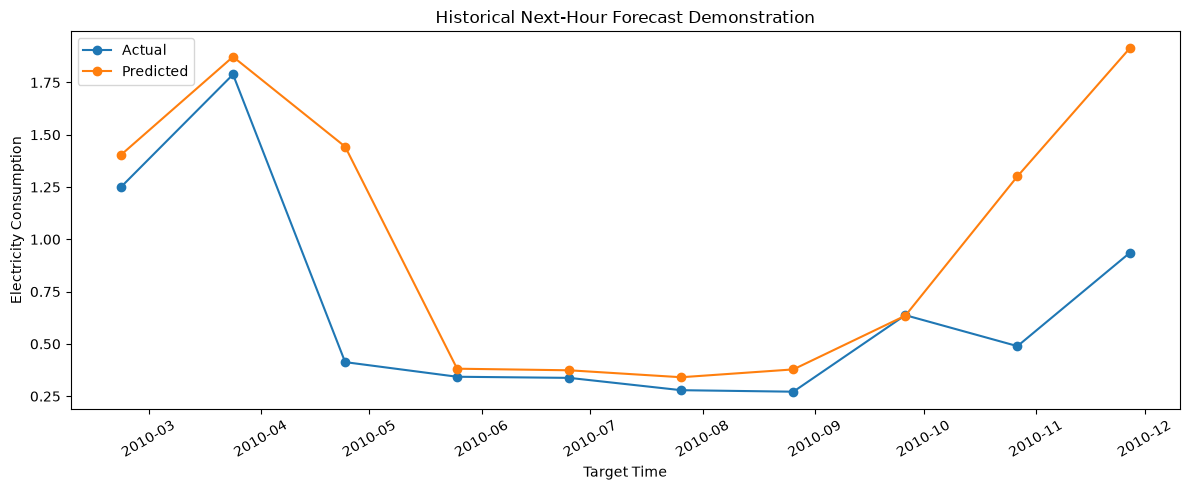

In [ ]:
plt.figure(figsize=(12, 5))

plt.plot(
    forecast_results_df["Target_Time"],
    forecast_results_df["Actual_Consumption"],
    marker="o",
    label="Actual"
)

plt.plot(
    forecast_results_df["Target_Time"],
    forecast_results_df["Predicted_Consumption"],
    marker="o",
    label="Predicted"
)

plt.title("Historical Next-Hour Forecast Demonstration")
plt.xlabel("Target Time")
plt.ylabel("Electricity Consumption")
plt.xticks(rotation=30)
plt.legend()
plt.tight_layout()
plt.show()


## 12. Demonstrate the Model on the Most Recent Historical Timestamp

This is the closest point to a live-style prediction that can be demonstrated from the historical dataset.

We need at least 168 hours of history to calculate the weekly lag and rolling features.


In [ ]:
valid_forecast_df = forecast_df.dropna(
    subset=feature_columns
)

latest_timestamp = valid_forecast_df.index[-2]

latest_prediction = forecast_next_hour(
    latest_timestamp,
    forecast_df,
    model
)

latest_target_time = (
    latest_timestamp + pd.Timedelta(hours=1)
)

latest_actual = forecast_df.loc[
    latest_target_time,
    "Electricity_Consumption"
]

print("Latest demonstration timestamp:", latest_timestamp)
print("Target timestamp:", latest_target_time)
print("Predicted consumption:", latest_prediction)
print("Actual consumption:", latest_actual)
print(
    "Absolute error:",
    abs(latest_actual - latest_prediction)
)


Latest demonstration timestamp: 2010-11-26 20:00:00
Target timestamp: 2010-11-26 21:00:00
Predicted consumption: 1.9124521821769525
Actual consumption: 0.9346666666666668
Absolute error: 0.9777855155102857


## 13. Save Demonstration Forecasts


In [ ]:
output_path = "../data/processed/forecast_demo_results.csv"

forecast_results_df.to_csv(
    output_path,
    index=False
)

print("Saved:", output_path)


Saved: ../data/processed/forecast_demo_results.csv


## 14. Final Validation


In [ ]:
print("===== FORECASTING DEMO SUMMARY =====")
print("Model:", type(model).__name__)
print("Feature count:", len(feature_columns))
print("Demonstration forecasts:", len(forecast_results_df))

print("\nLatest historical demonstration:")
print("Forecast time:", latest_timestamp)
print("Target time:", latest_target_time)
print("Prediction:", latest_prediction)
print("Actual:", latest_actual)
print("Absolute error:", abs(latest_actual - latest_prediction))


===== FORECASTING DEMO SUMMARY =====
Model: HistGradientBoostingRegressor
Feature count: 10
Demonstration forecasts: 10

Latest historical demonstration:
Forecast time: 2010-11-26 20:00:00
Target time: 2010-11-26 21:00:00
Prediction: 1.9124521821769525
Actual: 0.9346666666666668
Absolute error: 0.9777855155102857


## Conclusion

The trained model can now be used through a reusable forecasting function.

### Project pipeline completed so far

`Raw Data`

→ Data Loading

→ Data Cleaning

→ Hourly Aggregation

→ EDA

→ Feature Engineering

→ Time-Based Train/Test Split

→ Model Training

→ Model Evaluation

→ **Forecasting Demo**

### Next stage

**10 - Dashboard Preparation**

We will prepare the outputs required for a user-facing dashboard, including:

- consumption trends
- hourly patterns
- weekday/weekend comparison
- monthly patterns
- actual vs predicted consumption
- model performance
- next-hour prediction

After that, we can build the **Streamlit dashboard** and then prepare the final college report/presentation.
